# The Product Rule of Probability

This notebook explains the **product rule of probability**, which provides a way to calculate the joint probability of two events using their conditional and marginal probabilities.

## Deriving the Product Rule

The product rule is derived directly from the definition of conditional probability.

We know that the conditional probability of event A given event B is:

$P(A|B) = \frac{P(A \cap B)}{P(B)}$

By rearranging this formula, we can express the joint probability $P(A \cap B)$ as a product:

$P(A \cap B) = P(A|B)P(B)$

This is the **product rule**.

## Symmetry of the Product Rule

Because probability is symmetric, we can also write the conditional probability of B given A:

$P(B|A) = \frac{P(A \cap B)}{P(A)}$

Rearranging this gives us a second form of the product rule:

$P(A \cap B) = P(B|A)P(A)$

Both forms are equivalent and express the same core idea: the joint probability is the product of a conditional probability and a marginal probability.

## Formal Definition

The **product rule of probability** states that the joint probability of two random variables can be expressed as the product of the marginal probability of one random variable and the conditional probability of the other random variable conditioned on the first.

For two random variables, X and Y:

$P(X=x_i, Y=y_j) = P(X=x_i | Y=y_j) P(Y=y_j)$

and equivalently:

$P(X=x_i, Y=y_j) = P(Y=y_j | X=x_i) P(X=x_i)$

## Example: Colored Shapes

Let's use our colored shapes example to demonstrate the product rule. We want to find the joint probability of an object being a **Red Sphere**, i.e., $P(\text{Color=R}, \text{Shape=S})$.

We will use the conditional and marginal probabilities calculated previously.

In [1]:
import pandas as pd

# Data from previous notebooks
counts = pd.DataFrame(
    [[18, 12, 30],
     [16, 20, 4]],
    index=['Shape=S', 'Shape=C'],
    columns=['Color=R', 'Color=G', 'Color=B']
)

joint_prob = counts / counts.values.sum()
marginal_shape = joint_prob.sum(axis=1)
cond_prob_color_given_shape = joint_prob.divide(marginal_shape, axis=0)

# --- Using the Product Rule ---

# P(Color=R, Shape=S) = P(Color=R | Shape=S) * P(Shape=S)
p_color_r_given_shape_s = cond_prob_color_given_shape.loc['Shape=S', 'Color=R']
p_shape_s = marginal_shape.loc['Shape=S']

# Calculate the joint probability using the product rule
joint_p_calc = p_color_r_given_shape_s * p_shape_s

# Get the actual joint probability from the table for verification
joint_p_actual = joint_prob.loc['Shape=S', 'Color=R']

print(f"P(Color=R | Shape=S) = {p_color_r_given_shape_s:.2f}")
print(f"P(Shape=S) = {p_shape_s:.2f}")
print("---")
print(f"Product Rule Calculation: {p_color_r_given_shape_s:.2f} * {p_shape_s:.2f} = {joint_p_calc:.2f}")
print(f"Actual Joint Probability from table: {joint_p_actual:.2f}")
print(f"Verification: {'Success' if abs(joint_p_calc - joint_p_actual) < 1e-9 else 'Failure'}")

P(Color=R | Shape=S) = 0.30
P(Shape=S) = 0.60
---
Product Rule Calculation: 0.30 * 0.60 = 0.18
Actual Joint Probability from table: 0.18
Verification: Success


## Illustration with a Venn Diagram

The product rule can be visualized as finding the size of the intersection ($A \cap B$) by taking a fraction ($P(A|B)$) of a whole ($P(B)$).

- **$P(B)$** represents the area of the orange circle (our marginal probability).
- **$P(A|B)$** tells us what fraction of that orange circle is also covered by A (the conditional probability).

Multiplying them together gives us the absolute area of the intersection.

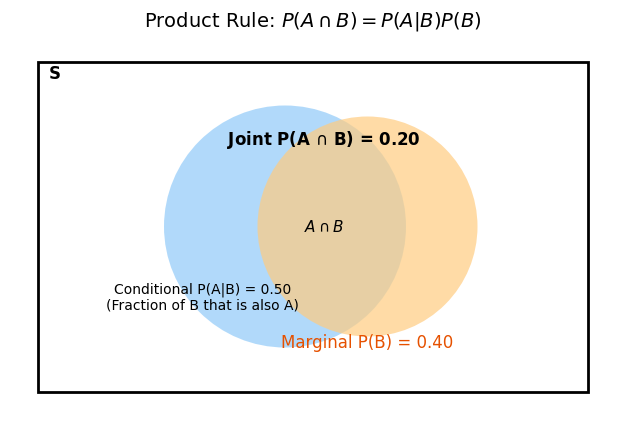

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# Probabilities
p_b = 0.40
p_a_given_b = 0.50
p_intersection = p_a_given_b * p_b # This is the product rule

fig, ax = plt.subplots(figsize=(8, 5))

# Draw circles
ax.add_patch(Rectangle((0, 0), 10, 6, fill=False, linewidth=2, edgecolor='black'))
ax.text(0.2, 5.7, 'S', fontsize=12, fontweight='bold')

circle_a = Circle((4.5, 3.0), 2.2, facecolor='#64b5f6', alpha=0.5)
circle_b = Circle((6.0, 3.0), 2.0, facecolor='#ffcc80', alpha=0.7)
ax.add_patch(circle_a)
ax.add_patch(circle_b)

# Highlight the intersection
ax.text(5.2, 3.0, f'$A \\cap B$', ha='center', va='center', fontsize=11, weight='bold')

# Annotations
ax.set_title('Product Rule: $P(A \\cap B) = P(A|B)P(B)$', fontsize=14)
ax.text(6.0, 0.8, f'Marginal P(B) = {p_b:.2f}', ha='center', fontsize=12, color='#e65100')
ax.text(3.0, 1.5, f'Conditional P(A|B) = {p_a_given_b:.2f}\n(Fraction of B that is also A)', ha='center', fontsize=10)
ax.text(5.2, 4.5, f'Joint P(A $\\cap$ B) = {p_intersection:.2f}', ha='center', fontsize=12, weight='bold')

ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

## Special Case: Independent Events

If two events, A and B, are **independent**, the occurrence of one does not affect the probability of the other. In this case:

$P(A|B) = P(A)$

Substituting this into the product rule gives the familiar formula for independent events:

$P(A \cap B) = P(A)P(B)$

## Summary

- The **Product Rule** is a rearrangement of the conditional probability formula used to find the joint probability of two events.
- **Formula:** $P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)$
- It connects joint, conditional, and marginal probabilities.
- For independent events, it simplifies to $P(A \cap B) = P(A)P(B)$.